In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

In [6]:
df = pd.read_csv('OnlineRetail.csv',encoding='latin1')

In [7]:
df.shape

(541909, 8)

In [8]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [10]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [12]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [13]:
df = df.dropna(subset=['CustomerID'])

In [14]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [16]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [17]:
customer_df = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'TotalPrice': 'sum'
}).reset_index()

In [18]:
customer_df.columns = ['CustomerID','NumTransactions','TotalQuantity','TotalSpending']

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df[['NumTransactions','TotalQuantity','TotalSpending']])

In [20]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

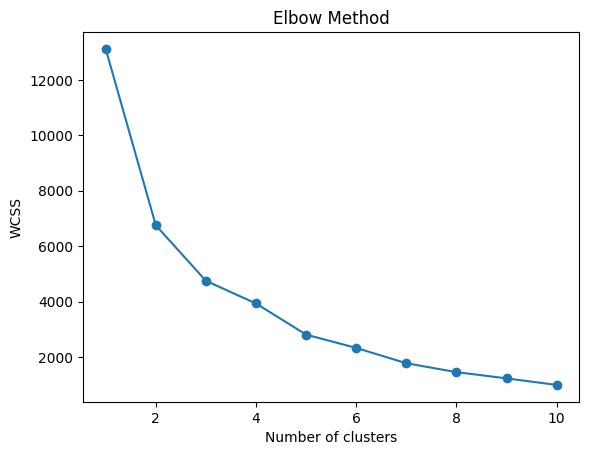

In [21]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)
customer_df['Cluster'] = kmeans.labels_

In [23]:
customer_df.groupby('Cluster').mean()

,CustomerID,NumTransactions,TotalQuantity,TotalSpending
Cluster,,,,
0,15304.861171,3.666426,644.727645,1068.077350
1,15439.555556,52.000000,77373.666667,136450.252222
2,14933.571429,154.428571,32984.000000,54499.597143
3,15202.082126,26.227053,6302.714976,10913.349952


In [25]:
customer_df.head()

,CustomerID,NumTransactions,TotalQuantity,TotalSpending,Cluster
0,12346.0,2,0,0.00,0
1,12347.0,7,2458,4310.00,0
2,12348.0,4,2341,1797.24,0
3,12349.0,1,631,1757.55,0
4,12350.0,1,197,334.40,0


In [26]:
customer_df['Cluster'].value_counts()

Cluster
0    4149
3     207
1       9
2       7
Name: count, dtype: int64

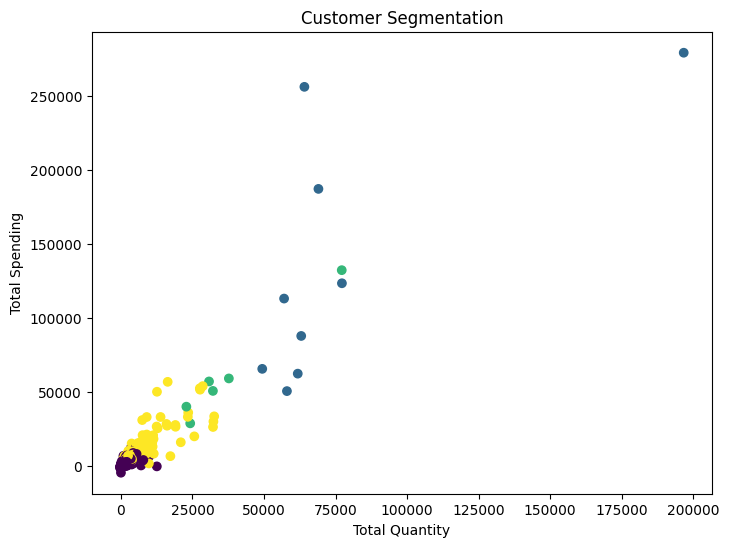

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    customer_df['TotalQuantity'],
    customer_df['TotalSpending'],
    c=customer_df['Cluster']
)

plt.xlabel("Total Quantity")
plt.ylabel("Total Spending")
plt.title("Customer Segmentation")

plt.show()

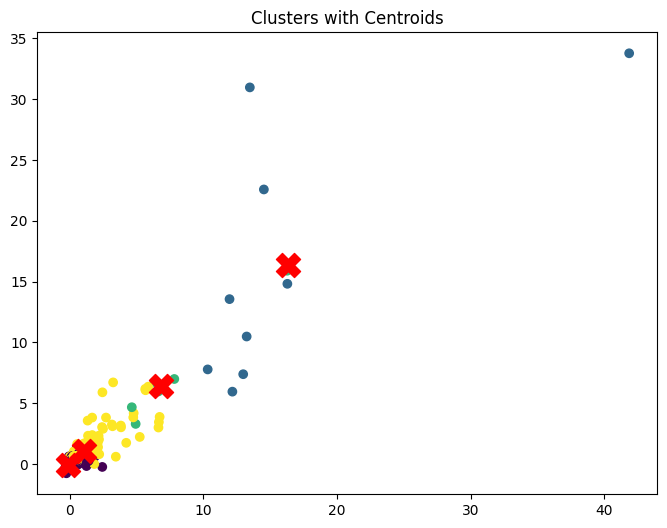

In [28]:
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,1],
    X_scaled[:,2],
    c=customer_df['Cluster']
)

plt.scatter(
    centroids[:,1],
    centroids[:,2],
    s=300,
    c='red',
    marker='X'
)

plt.title("Clusters with Centroids")

plt.show()